# Model B — Jockeying (both directions) on $\widetilde{S}$
### $\gamma_1, \gamma_2 > 0$,  $\theta_1 = \theta_2 = 0$

Jockeying moves customers between queues *without removing them*. In state space
$\widetilde{S}$ this means transitions that change $n_2$ at **fixed $n$**: a
class-1 customer who jockeys increases $n_2 \to n_2{+}1$ (and $n_1 \to n_1{-}1$),
keeping the total $n$ constant. Consequently:

* The **total queue marginal** $\widetilde{P}(1,n)=(1-\rho)\rho^{n+1}$ is
  **invariant** under any $(\gamma_1, \gamma_2)$ — jockeying cannot change $\rho$.
* The **within-column redistribution** of $\widetilde{\pi}(n_2,n)$ over $n_2$
  *does* change with $\gamma_i$.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── shared plotting helpers ───────────────────────────────────────────────────

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False, vmin=None, vmax=None):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        vm  = vmin or 1e-6
        vM  = vmax or float(np.nanmax(grid))
        im  = ax.imshow(grid, origin="lower", cmap="viridis",
                        norm=LogNorm(vmin=vm, vmax=vM))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin or 0, vmax=vmax or float(np.nanmax(grid)))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    ax.plot([0, nmax], [0, nmax], "w--", lw=0.8, alpha=0.6)
    return im

def ppgf_panel(ax, pi_tilde, p, ns=(1,2,3,5,8), show_approx=False, label_suffix=""):
    y = np.linspace(0.0, 1.0, 201)
    cols = plt.cm.viridis(np.linspace(0.15, 0.9, len(ns)))
    for n, c in zip(ns, cols):
        ax.plot(y, P_tilde(y, n, pi_tilde), color=c, lw=2.0,
                label=rf"$n={n}${label_suffix}")
        if show_approx:
            ax.plot(y, P_tilde_approx_modelA(y, n, p), color=c,
                    lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$\widetilde{P}(y,n)$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

def marginals_panel(ax, pi_tilde, kmax=14):
    m = marginals_tilde(pi_tilde)
    k = np.arange(min(kmax+1, len(m["pi_n1"])))
    ax.bar(k - 0.2, m["pi_n1"][:len(k)], 0.4, label=r"$\pi(n_1)$",
           color="#1f3a93", alpha=0.85)
    ax.bar(k + 0.2, m["pi_n2"][:len(k)], 0.4, label=r"$\pi(n_2)$",
           color="#c0392b", alpha=0.85)
    ax.set_xlabel("queue count"); ax.set_ylabel("probability")
    ax.legend(); ax.grid(alpha=0.3)

def metrics_row(name, p, r):
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name:<28} pi_0={r['pi_idle']:.4f}  P(busy)={d['P_busy']:.4f}"
          f"  E[N1]={d['E_n1']:.3f}  E[N2]={d['E_n2']:.3f}"
          f"  E[N]={d['E_n']:.3f}  throughput={d['throughput']:.4f}")

In [2]:
p_A  = Params(0.3, 0.4, 1.0)                        # reference
p_B  = Params(0.3, 0.4, 1.0, gamma1=0.5, gamma2=0.3)

r_A  = solve_exact_tilde(p_A, n_max=60)
r_B  = solve_exact_tilde(p_B, n_max=60)

print("Cross-validate (jockeying preserves pi_0, pi(0,0), E[N]):")
for name, pm, r in [("Model A", p_A, r_A), ("Model B", p_B, r_B)]:
    metrics_row(name, pm, r)

Cross-validate (jockeying preserves pi_0, pi(0,0), E[N]):
  Model A                      pi_0=0.3000  P(busy)=0.7000  E[N1]=0.300  E[N2]=1.333  E[N]=1.633  throughput=0.7000
  Model B                      pi_0=0.3000  P(busy)=0.7000  E[N1]=0.515  E[N2]=1.118  E[N]=1.633  throughput=0.7000


## 1. Joint distribution: Model A vs Model B

Jockeying redistributes mass *within each column* $n=\text{const}$ of the triangle.
$\gamma_1>0$ pushes mass toward larger $n_2$ (class-1 moves to class-2 queue).
$\gamma_2>0$ pushes it back.

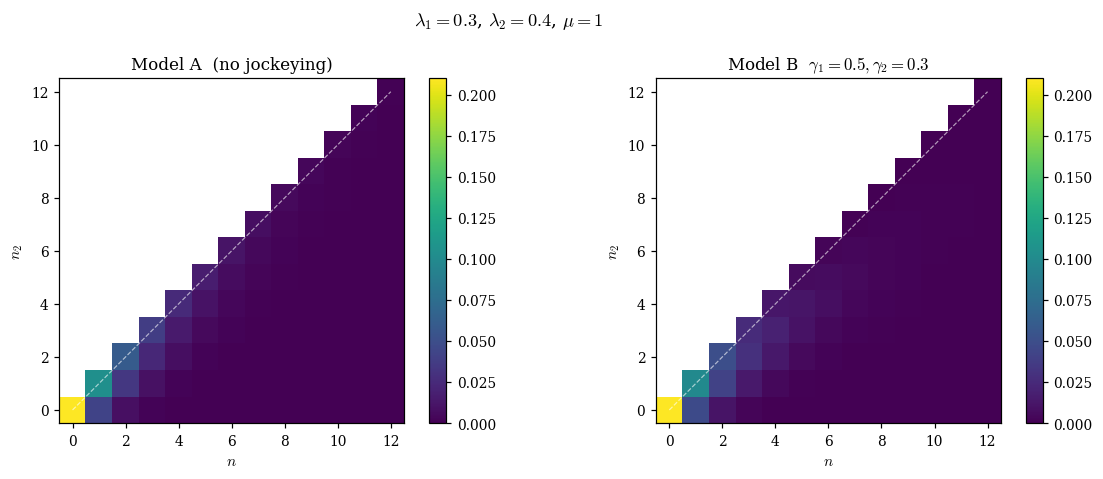

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
vmax = max(np.nanmax(r_A["pi_tilde"][:13,:13]),
           np.nanmax(r_B["pi_tilde"][:13,:13]))
for ax, (r, name) in zip(axes, [(r_A, "Model A  (no jockeying)"),
                                 (r_B, rf"Model B  $\gamma_1=0.5,\gamma_2=0.3$")]):
    im = tilde_heatmap(ax, r["pi_tilde"], name, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"{p_A.label()}")
fig.tight_layout()

## 2. Within-column profile: $\widetilde{\pi}(n_2, n)$ for fixed $n$

For each total queue length $n$, how is the mass spread over $n_2 \in [0,n]$?

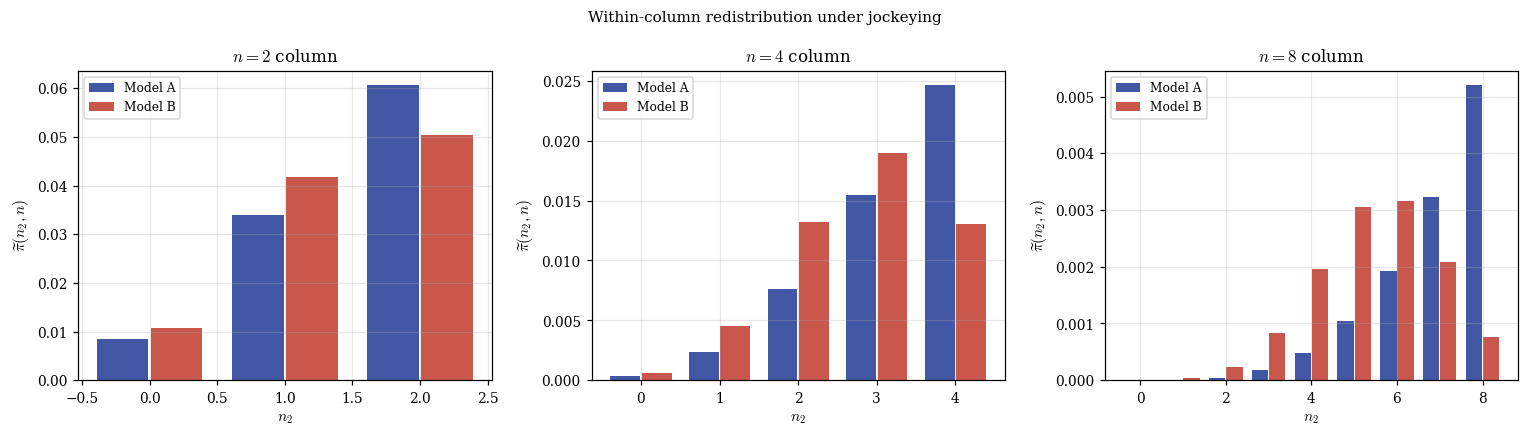

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, n in zip(axes, [2, 4, 8]):
    n2vals = np.arange(n + 1)
    col_A = np.array([r_A["pi_tilde"][n2, n] for n2 in n2vals])
    col_B = np.array([r_B["pi_tilde"][n2, n] for n2 in n2vals])
    ax.bar(n2vals - 0.2, col_A, 0.38, label="Model A", color="#1f3a93", alpha=0.85)
    ax.bar(n2vals + 0.2, col_B, 0.38, label="Model B", color="#c0392b", alpha=0.85)
    ax.set_xlabel(r"$n_2$"); ax.set_ylabel(r"$\widetilde{\pi}(n_2, n)$")
    ax.set_title(rf"$n = {n}$ column"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Within-column redistribution under jockeying", fontsize=10)
fig.tight_layout()

## 3. Invariance of the total queue marginal

The marginal $\widetilde{P}(1,n) = \mathbb{P}(N=n,\text{busy})$ must equal
$(1-\rho)\rho^{n+1}$ for **any** choice of $\gamma_i$.

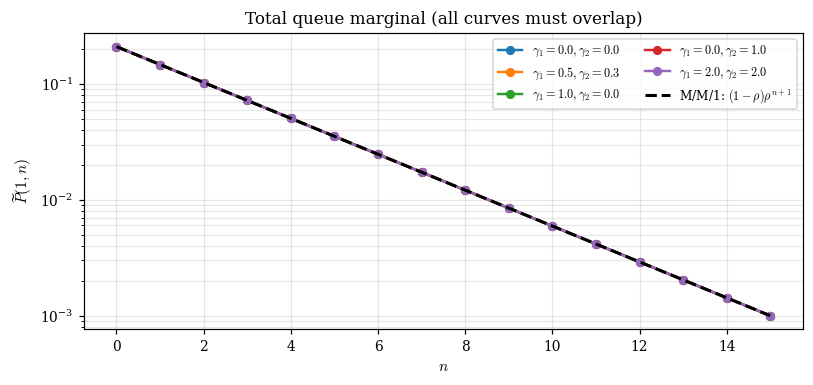

In [5]:
gammas = [(0.0, 0.0), (0.5, 0.3), (1.0, 0.0), (0.0, 1.0), (2.0, 2.0)]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ns = np.arange(16)
for g1, g2 in gammas:
    pg = Params(0.3, 0.4, 1.0, gamma1=g1, gamma2=g2)
    rg = solve_exact_tilde(pg, n_max=60)
    Pn = [float(P_tilde(1.0, n, rg["pi_tilde"])) for n in ns]
    ax.plot(ns, Pn, "o-", ms=5, lw=1.6,
            label=rf"$\gamma_1={g1},\gamma_2={g2}$")
ax.plot(ns, (1-p_A.rho)*p_A.rho**(ns+1), "k--", lw=2.0,
        label=r"M/M/1: $(1-\rho)\rho^{n+1}$")
ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$\widetilde{P}(1, n)$")
ax.set_yscale("log"); ax.set_title("Total queue marginal (all curves must overlap)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

## 4. PPGF $\widetilde{P}(y,n)$ curves

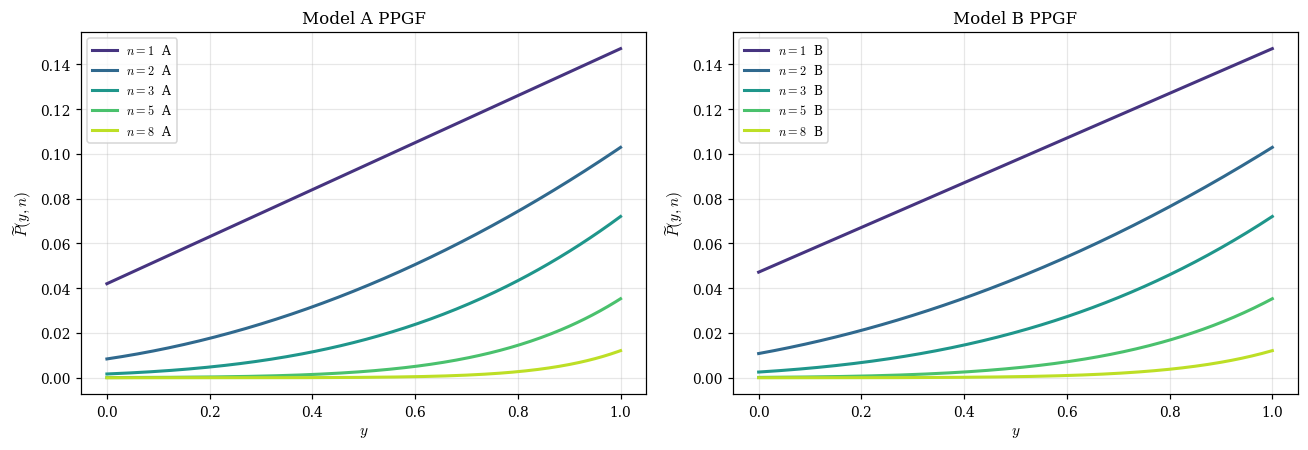

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ppgf_panel(axes[0], r_A["pi_tilde"], p_A, label_suffix="  A")
ppgf_panel(axes[1], r_B["pi_tilde"], p_B, label_suffix="  B")
axes[0].set_title("Model A PPGF"); axes[1].set_title("Model B PPGF")
fig.tight_layout()

## 5. Effect of $\gamma_1$ and $\gamma_2$ on mean queue lengths

Because $E[N] = E[N_1]+E[N_2]$ is invariant, increasing $\gamma_1$
(class-1 → class-2 migration) lowers $E[N_1]$ and raises $E[N_2]$ by the same amount.

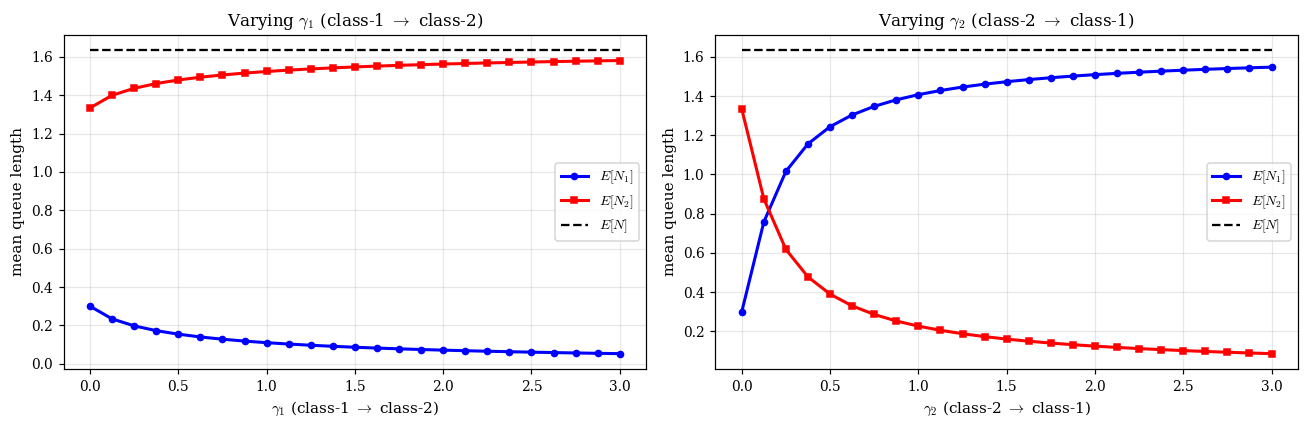

In [7]:
g_vals = np.linspace(0.0, 3.0, 25)
mu_b = 1.0

# sweep gamma1, keep gamma2=0
En1_g1, En2_g1 = [], []
for g in g_vals:
    r_g = solve_exact_tilde(Params(0.3, 0.4, mu_b, gamma1=g), n_max=60)
    d   = diagnostics_tilde(Params(0.3, 0.4, mu_b, gamma1=g), r_g["pi_idle"], r_g["pi_tilde"])
    En1_g1.append(d["E_n1"]); En2_g1.append(d["E_n2"])

# sweep gamma2, keep gamma1=0
En1_g2, En2_g2 = [], []
for g in g_vals:
    r_g = solve_exact_tilde(Params(0.3, 0.4, mu_b, gamma2=g), n_max=60)
    d   = diagnostics_tilde(Params(0.3, 0.4, mu_b, gamma2=g), r_g["pi_idle"], r_g["pi_tilde"])
    En1_g2.append(d["E_n1"]); En2_g2.append(d["E_n2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
for ax, (En1, En2, g_lbl) in zip(axes, [
    (En1_g1, En2_g1, r"$\gamma_1$ (class-1 $\to$ class-2)"),
    (En1_g2, En2_g2, r"$\gamma_2$ (class-2 $\to$ class-1)"),
]):
    ax.plot(g_vals, En1, "b-o", ms=4, lw=2, label=r"$E[N_1]$")
    ax.plot(g_vals, En2, "r-s", ms=4, lw=2, label=r"$E[N_2]$")
    ax.plot(g_vals, np.array(En1)+np.array(En2), "k--", lw=1.5, label=r"$E[N]$")
    ax.set_xlabel(g_lbl); ax.set_ylabel("mean queue length")
    ax.set_title(f"Varying {g_lbl}"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()